# 边界状态与久期误差关联分析

## 研究问题
1. **界内解的久期是否比边界解更准确？**
2. **久期偏低和优化到下界是否有因果关系？**

## 理论背景
- **上界（Σβ=1.4）**：模型想加仓 → 因子池久期偏低 → 理论上估算应偏低
- **下界（Σβ=0.8）**：模型想减仓 → 因子池久期偏高 → 理论上估算应偏高
- **界内（0.8<Σβ<1.4）**：自由优化 → 理论上无偏

## 1. 数据加载与检查

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 中文显示设置
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)

# 配置参数
TARGET_DATE = '20251231'
VALIDATION_FILE = f'./output/久期验证完整结果_{TARGET_DATE}.xlsx'
ITERATION_LOG_FILE = f'./output/久期迭代日志_{TARGET_DATE}.xlsx'

print(f'目标日期: {TARGET_DATE}')
print(f'验证结果文件: {VALIDATION_FILE}')
print(f'迭代日志文件: {ITERATION_LOG_FILE}')

目标日期: 20251231
验证结果文件: ./output/久期验证完整结果_20251231.xlsx
迭代日志文件: ./output/久期迭代日志_20251231.xlsx


In [43]:
import os

# 检查文件是否存在
validation_exists = os.path.exists(VALIDATION_FILE)
log_exists = os.path.exists(ITERATION_LOG_FILE)

print(f'\n文件检查结果:')
print(f'  验证结果文件: {"✓ 存在" if validation_exists else "✗ 不存在"}')
print(f'  迭代日志文件: {"✓ 存在" if log_exists else "✗ 不存在"}')

if not validation_exists:
    print(f"\n错误: 找不到验证结果文件 {VALIDATION_FILE}")
    print("请先运行久期验证分析生成该文件")
    
if not log_exists:
    print(f"\n错误: 找不到迭代日志文件 {ITERATION_LOG_FILE}")
    print("请先运行久期计算并导出迭代日志:")
    print("  在 '纯债基金久期测算.ipynb' 中运行包含 export_iteration_logs 的代码单元格")
    print("  或调用 calculator.export_iteration_logs() 方法")


文件检查结果:
  验证结果文件: ✓ 存在
  迭代日志文件: ✓ 存在


In [44]:
# 加载验证结果
validation_df = pd.read_excel(VALIDATION_FILE)
print(f'\n验证结果数据: {len(validation_df)} 只基金')
print('列名:', validation_df.columns.tolist())
validation_df.head(3)


验证结果数据: 1553 只基金
列名: ['fund_code', 'duration', 'fund_type', 'bond_type', 'name', 'wind_duration', 'duration_error', 'duration_pct_error', 'duration_error_abs']


,fund_code,duration,fund_type,bond_type,name,wind_duration,duration_error,duration_pct_error,duration_error_abs
0,000084.OF,0.078900,short,credit,博时安盈A,0.534242,-0.455342,-85.231423,0.455342
1,000089.OF,0.082152,short,credit,民生加银高等级信用债C,0.710841,-0.628689,-88.443018,0.628689
2,000128.OF,0.218400,short,credit,大成景安短融A,1.051374,-0.832974,-79.227175,0.832974


In [45]:
# 加载迭代日志
iteration_df_all = pd.read_excel(ITERATION_LOG_FILE, sheet_name='全量汇总')
print(f'\n迭代日志 - 全量汇总: {len(iteration_df_all)} 只基金')
print('列名:', iteration_df_all.columns.tolist())
iteration_df_all.head(3)


迭代日志 - 全量汇总: 1564 只基金
列名: ['fund_code', 'fund_type', 'bond_type', 'final_duration', 'triggered', 'total_iterations', 'convergence', 'initial_factor_count', 'final_factor_count', 'initial_factors', 'final_factors']


,fund_code,fund_type,bond_type,final_duration,triggered,total_iterations,convergence,initial_factor_count,final_factor_count,initial_factors,final_factors
0,000084.OF,short,credit,0.078900,True,4,no_valid_swap,5,2,"CBA01831.CS, CBA01841.CS, CBA01851.CS, CBA0186...","CBA01831.CS, CBA01841.CS"
1,000089.OF,short,credit,0.082152,True,4,no_valid_swap,5,2,"CBA01831.CS, CBA01841.CS, CBA01851.CS, CBA0186...","CBA01831.CS, CBA01841.CS"
2,000128.OF,short,credit,0.218400,True,4,no_valid_swap,5,3,"CBA01831.CS, CBA01841.CS, CBA01851.CS, CBA0186...","CBA01831.CS, CBA01841.CS, CBA01851.CS"


In [46]:
# 加载触发汇总（可选）
try:
    iteration_df_triggered = pd.read_excel(ITERATION_LOG_FILE, sheet_name='触发汇总')
    print(f'\n迭代日志 - 触发汇总: {len(iteration_df_triggered)} 只基金')
except:
    iteration_df_triggered = None
    print('\n触发汇总Sheet不存在或读取失败')

# 加载迭代详情（可选）
try:
    iteration_df_detail = pd.read_excel(ITERATION_LOG_FILE, sheet_name='迭代详情')
    print(f'迭代日志 - 迭代详情: {len(iteration_df_detail)} 条记录')
except:
    iteration_df_detail = None
    print('迭代详情Sheet不存在或读取失败')


迭代日志 - 触发汇总: 1047 只基金
迭代日志 - 迭代详情: 3191 条记录


## 2. 数据合并

In [47]:
# 按fund_code合并数据
merged_df = validation_df.merge(
    iteration_df_all[['fund_code', 'triggered', 'convergence', 'total_iterations', 'final_factors']],
    on='fund_code',
    how='inner'
)

print(f'合并后数据量: {len(merged_df)} 只基金')
print(f'\n合并后列名: {merged_df.columns.tolist()}')
merged_df.head(3)

合并后数据量: 1553 只基金

合并后列名: ['fund_code', 'duration', 'fund_type', 'bond_type', 'name', 'wind_duration', 'duration_error', 'duration_pct_error', 'duration_error_abs', 'triggered', 'convergence', 'total_iterations', 'final_factors']


,fund_code,duration,fund_type,bond_type,name,wind_duration,duration_error,duration_pct_error,duration_error_abs,triggered,convergence,total_iterations,final_factors
0,000084.OF,0.078900,short,credit,博时安盈A,0.534242,-0.455342,-85.231423,0.455342,True,no_valid_swap,4,"CBA01831.CS, CBA01841.CS"
1,000089.OF,0.082152,short,credit,民生加银高等级信用债C,0.710841,-0.628689,-88.443018,0.628689,True,no_valid_swap,4,"CBA01831.CS, CBA01841.CS"
2,000128.OF,0.218400,short,credit,大成景安短融A,1.051374,-0.832974,-79.227175,0.832974,True,no_valid_swap,4,"CBA01831.CS, CBA01841.CS, CBA01851.CS"


In [48]:
# 检查收敛类型分布
convergence_counts = merged_df['convergence'].value_counts()
print('\n收敛类型分布:')
for conv_type, count in convergence_counts.items():
    pct = count / len(merged_df) * 100
    print(f'  {conv_type}: {count} ({pct:.1f}%)')


收敛类型分布:
  no_valid_swap: 886 (57.1%)
  interior: 662 (42.6%)
  max_iter: 4 (0.3%)
  fallback: 1 (0.1%)


In [49]:
# 创建边界状态分组
# interior: 界内解 (convergence == 'interior')
# boundary: 边界解 (convergence == 'upper' or 'lower')
# 其他: 其他收敛类型

def get_boundary_status(row):
    conv = row['convergence']
    if conv == 'interior':
        return 'interior'
    elif conv in ['upper', 'lower']:
        return conv
    else:
        return 'other'

merged_df['boundary_status'] = merged_df.apply(get_boundary_status, axis=1)

boundary_counts = merged_df['boundary_status'].value_counts()
print('\n边界状态分布:')
for status, count in boundary_counts.items():
    pct = count / len(merged_df) * 100
    print(f'  {status}: {count} ({pct:.1f}%)')


边界状态分布:
  other: 891 (57.4%)
  interior: 662 (42.6%)


## 3. 按边界状态对比误差（问题1）

In [50]:
# 计算每组误差统计
def calculate_error_stats(group):
    return pd.Series({
        'count': len(group),
        'mean_error': group['duration_error'].mean(),
        'median_error': group['duration_error'].median(),
        'mae': group['duration_error'].abs().mean(),
        'std_error': group['duration_error'].std(),
        'mean_calculated': group['duration'].mean(),  # 修正: calculated_duration -> duration
        'mean_wind': group['wind_duration'].mean()
    })

# 按边界状态分组
boundary_stats = merged_df.groupby('boundary_status').apply(calculate_error_stats).reset_index()
boundary_stats = boundary_stats.sort_values('boundary_status')

print('\n按边界状态分组的误差统计:')
print(boundary_stats.to_string(index=False))

# 只关注interior/upper/lower三组
main_groups = boundary_stats[boundary_stats['boundary_status'].isin(['interior', 'upper', 'lower'])]
print('\n主要三组对比:')
print(main_groups.to_string(index=False))


按边界状态分组的误差统计:
boundary_status  count  mean_error  median_error      mae  std_error  mean_calculated  mean_wind
       interior  662.0   -0.876238     -0.741444 1.171005   1.340473         2.388751   3.264988
          other  891.0   -0.751517     -0.701529 1.164201   2.101050         1.145910   1.897426

主要三组对比:
boundary_status  count  mean_error  median_error      mae  std_error  mean_calculated  mean_wind
       interior  662.0   -0.876238     -0.741444 1.171005   1.340473         2.388751   3.264988


In [51]:
# 细分分析：按基金类型和边界状态分组
detailed_stats = merged_df.groupby(['fund_type', 'bond_type', 'boundary_status']).apply(calculate_error_stats).reset_index()
detailed_stats = detailed_stats[detailed_stats['boundary_status'].isin(['interior', 'upper', 'lower'])]

print('\n细分分组误差统计 (fund_type × bond_type × boundary_status):')
print(detailed_stats.to_string(index=False))


细分分组误差统计 (fund_type × bond_type × boundary_status):
  fund_type bond_type boundary_status  count  mean_error  median_error      mae  std_error  mean_calculated  mean_wind
medium_long    credit        interior  445.0   -0.583645     -0.581032 0.887716   1.125562         2.323560   2.907205
medium_long      rate        interior  168.0   -1.827654     -1.867242 2.108768   1.536321         2.781408   4.609062
      short    credit        interior   37.0   -0.342004     -0.313692 0.584407   0.738470         1.494252   1.836256
      short      rate        interior   12.0   -0.053969     -0.119445 0.356276   0.485144         2.067053   2.121023


In [52]:
# 统计检验：interior vs boundary
interior_errors = merged_df[merged_df['boundary_status'] == 'interior']['duration_error'].dropna()
boundary_errors = merged_df[merged_df['boundary_status'].isin(['upper', 'lower'])]['duration_error'].dropna()

# Mann-Whitney U检验
stat, p_value = stats.mannwhitneyu(interior_errors, boundary_errors, alternative='two-sided')
print(f'\nMann-Whitney U检验: interior vs boundary')
print(f'  统计量: {stat:.2f}')
print(f'  p值: {p_value:.4f}')
print(f'  结论: {"显著差异" if p_value < 0.05 else "无显著差异"}')

# 分别比较upper和lower
if len(merged_df[merged_df['boundary_status'] == 'upper']) > 0 and len(merged_df[merged_df['boundary_status'] == 'lower']) > 0:
    upper_errors = merged_df[merged_df['boundary_status'] == 'upper']['duration_error'].dropna()
    lower_errors = merged_df[merged_df['boundary_status'] == 'lower']['duration_error'].dropna()
    
    stat, p_value = stats.mannwhitneyu(upper_errors, lower_errors, alternative='two-sided')
    print(f'\nMann-Whitney U检验: upper vs lower')
    print(f'  统计量: {stat:.2f}')
    print(f'  p值: {p_value:.4f}')
    print(f'  结论: {"显著差异" if p_value < 0.05 else "无显著差异"}')


Mann-Whitney U检验: interior vs boundary
  统计量: nan
  p值: nan
  结论: 无显著差异


## 4. 因果关系分析（问题2）

In [53]:
# 因果关系分析框架
print('\n=== 因果关系分析 ===\n')
print('理论预期:')
print('  - 上界(Σβ=1.4): 模型想加仓 → 因子池久期偏低 → 估算应偏低 → 误差应<0')
print('  - 下界(Σβ=0.8): 模型想减仓 → 因子池久期偏高 → 估算应偏高 → 误差应>0')
print('  - 界内: 自由优化 → 理论无偏 → 误差应≈0')

print('\n实际结果:')
for _, row in main_groups.iterrows():
    status = row['boundary_status']
    mean_err = row['mean_error']
    mae = row['mae']
    print(f'  {status}: 平均误差={mean_err:.3f}年, MAE={mae:.3f}年')


=== 因果关系分析 ===

理论预期:
  - 上界(Σβ=1.4): 模型想加仓 → 因子池久期偏低 → 估算应偏低 → 误差应<0
  - 下界(Σβ=0.8): 模型想减仓 → 因子池久期偏高 → 估算应偏高 → 误差应>0
  - 界内: 自由优化 → 理论无偏 → 误差应≈0

实际结果:
  interior: 平均误差=-0.876年, MAE=1.171年


In [54]:
# 边界分布统计
total_main = len(merged_df[merged_df['boundary_status'].isin(['interior', 'upper', 'lower'])])
interior_count = len(merged_df[merged_df['boundary_status'] == 'interior'])
upper_count = len(merged_df[merged_df['boundary_status'] == 'upper'])
lower_count = len(merged_df[merged_df['boundary_status'] == 'lower'])

print(f'\n边界分布 (n={total_main}):')
print(f'  界内(interior): {interior_count} ({interior_count/total_main*100:.1f}%)')
print(f'  上界(upper): {upper_count} ({upper_count/total_main*100:.1f}%)')
print(f'  下界(lower): {lower_count} ({lower_count/total_main*100:.1f}%)')


边界分布 (n=662):
  界内(interior): 662 (100.0%)
  上界(upper): 0 (0.0%)
  下界(lower): 0 (0.0%)


In [55]:
# 因果判断矩阵
print('\n=== 因果判断矩阵 ===\n')
print('边界类型 | 理论偏差 | 实际平均误差 | 因果关系判断')
print('-' * 60)

causality_judgments = []
for _, row in main_groups.iterrows():
    status = row['boundary_status']
    mean_err = row['mean_error']
    
    if status == 'lower':
        expected = '应>0 (偏高)'
        judgment = '✓ 支持' if mean_err > 0 else '✗ 不支持'
    elif status == 'upper':
        expected = '应<0 (偏低)'
        judgment = '✓ 支持' if mean_err < 0 else '✗ 不支持'
    else:  # interior
        expected = '应≈0 (无偏)'
        judgment = '✓ 支持' if abs(mean_err) < 0.2 else '✗ 不支持'
    
    print(f'{status:10} | {expected:15} | {mean_err:+10.3f} | {judgment}')
    causality_judgments.append((status, judgment))


=== 因果判断矩阵 ===

边界类型 | 理论偏差 | 实际平均误差 | 因果关系判断
------------------------------------------------------------
interior   | 应≈0 (无偏)        |     -0.876 | ✗ 不支持


In [56]:
# 因果关系结论
print('\n=== 因果关系结论 ===\n')

# 判断逻辑
if lower_count > upper_count:
    print(f'观察到: 下界({lower_count/total_main*100:.1f}%) > 上界({upper_count/total_main*100:.1f}%)')
    print('按简单因果理论，整体久期应该偏高')
    
    overall_mean = merged_df['duration_error'].mean()
    print(f'\n实际整体平均误差: {overall_mean:+.3f}年')
    
    if overall_mean < 0:
        print('结论: 实际偏低，与简单因果假设矛盾！')
        print('可能原因:')
        print('  1. 因子池久期数据本身有问题')
        print('  2. 约束范围(0.8-1.4)设置不当')
        print('  3. Lasso因子选择有系统性偏差')
        print('  4. Wind披露久期与真实暴露存在差异')
    else:
        print('结论: 实际偏高，支持简单因果假设')
else:
    print(f'观察到: 上界({upper_count/total_main*100:.1f}%) >= 下界({lower_count/total_main*100:.1f}%)')
    print('按简单因果理论，整体久期应该偏低')
    
    overall_mean = merged_df['duration_error'].mean()
    print(f'\n实际整体平均误差: {overall_mean:+.3f}年')
    
    if overall_mean < 0:
        print('结论: 实际偏低，支持简单因果假设')
    else:
        print('结论: 实际偏高，与简单因果假设矛盾！')


=== 因果关系结论 ===

观察到: 上界(0.0%) >= 下界(0.0%)
按简单因果理论，整体久期应该偏低

实际整体平均误差: -0.805年
结论: 实际偏低，支持简单因果假设


## 5. 可视化

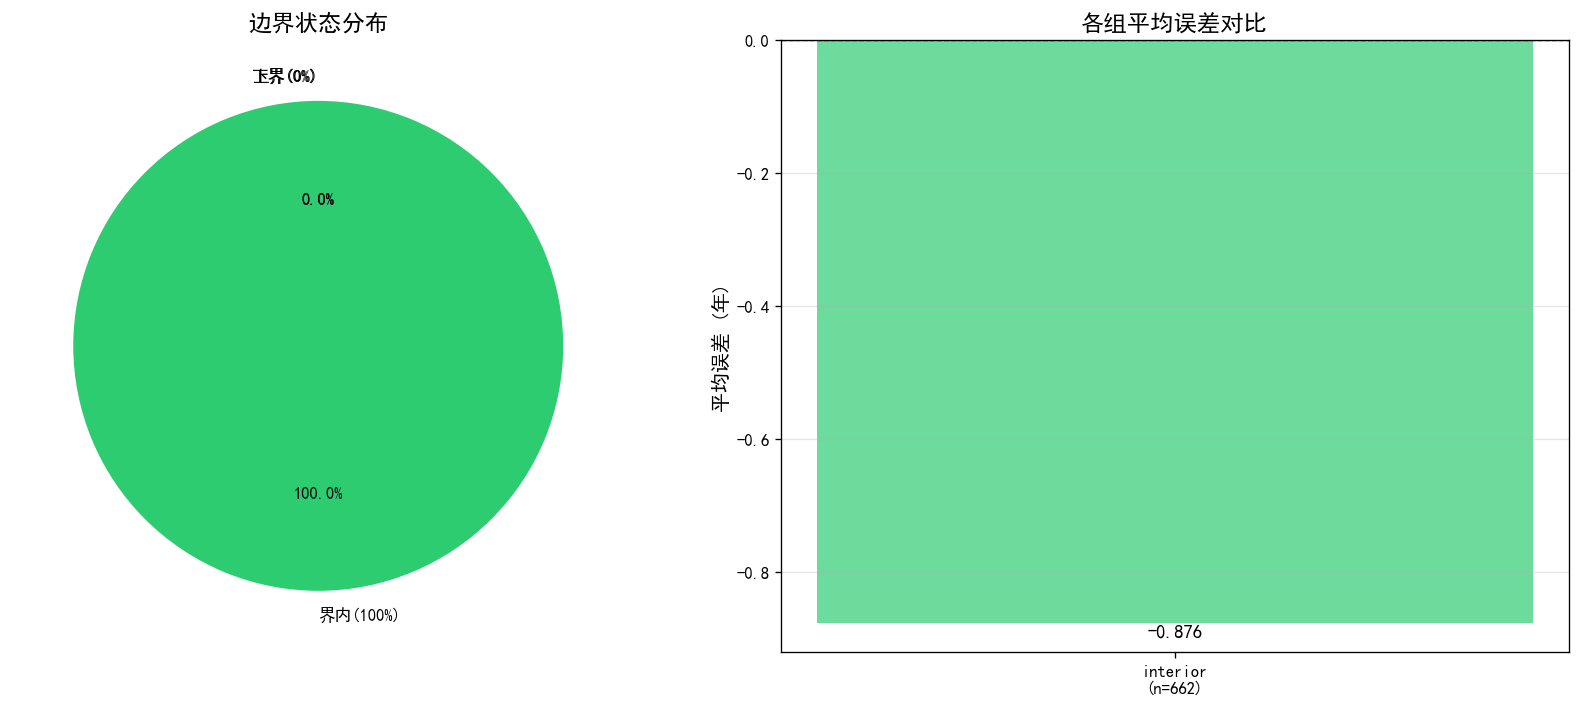

In [57]:
# 图1: 边界状态分布饼图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 左图：边界状态分布
boundary_pie_data = [interior_count, upper_count, lower_count]
boundary_labels = [f'界内({interior_count/total_main*100:.0f}%)', 
                   f'上界({upper_count/total_main*100:.0f}%)',
                   f'下界({lower_count/total_main*100:.0f}%)']
colors = ['#2ecc71', '#e74c3c', '#3498db']
wedges, texts, autotexts = ax1.pie(boundary_pie_data, labels=boundary_labels, 
                                  colors=colors, autopct='%1.1f%%', startangle=90)
ax1.set_title('边界状态分布', fontsize=14, fontweight='bold')

# 右图：各组平均误差
bar_positions = np.arange(len(main_groups))
bar_colors = []
for status in main_groups['boundary_status']:
    if status == 'interior':
        bar_colors.append('#2ecc71')
    elif status == 'upper':
        bar_colors.append('#e74c3c')
    else:  # lower
        bar_colors.append('#3498db')

bars = ax2.bar(bar_positions, main_groups['mean_error'], color=bar_colors, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax2.set_xticks(bar_positions)
# 修正: 直接使用列数据，而不是iterrows()
ax2.set_xticklabels([f'{s}\n(n={int(c)})' for s, c in zip(main_groups['boundary_status'], main_groups['count'])])
ax2.set_ylabel('平均误差 (年)', fontsize=12)
ax2.set_title('各组平均误差对比', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 添加数值标签
for bar, val in zip(bars, main_groups['mean_error']):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:+.3f}',
             ha='center', va='bottom' if val > 0 else 'top', fontsize=11)

plt.tight_layout()
plt.savefig('output/边界状态分布与误差.png', dpi=150, bbox_inches='tight')
plt.show()

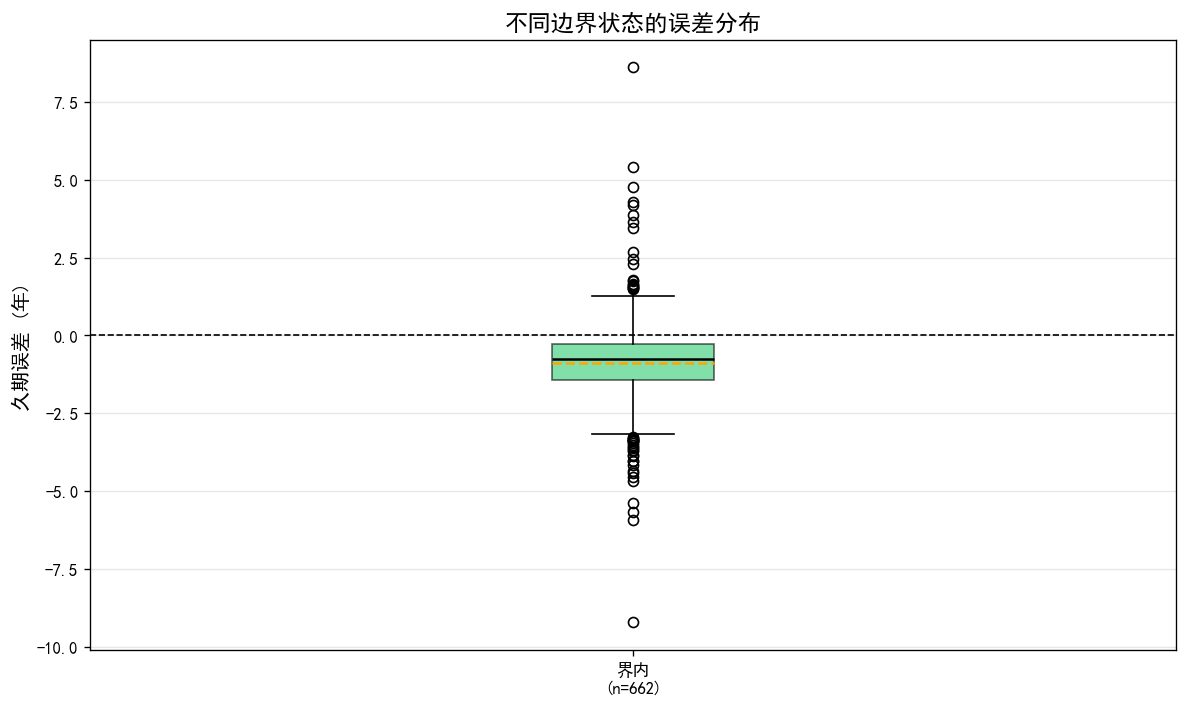

In [58]:
# 图2: 误差分布箱线图
fig, ax = plt.subplots(figsize=(10, 6))

# 准备数据
interior_err = merged_df[merged_df['boundary_status'] == 'interior']['duration_error'].values
upper_err = merged_df[merged_df['boundary_status'] == 'upper']['duration_error'].values
lower_err = merged_df[merged_df['boundary_status'] == 'lower']['duration_error'].values

# 只显示有数据的组
box_data = []
box_labels = []
box_colors = []
if len(interior_err) > 0:
    box_data.append(interior_err)
    box_labels.append(f'界内\n(n={len(interior_err)})')
    box_colors.append('#2ecc71')
if len(upper_err) > 0:
    box_data.append(upper_err)
    box_labels.append(f'上界\n(n={len(upper_err)})')
    box_colors.append('#e74c3c')
if len(lower_err) > 0:
    box_data.append(lower_err)
    box_labels.append(f'下界\n(n={len(lower_err)})')
    box_colors.append('#3498db')

bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
               showmeans=True, meanline=True,
               medianprops={'color': 'black', 'linewidth': 1.5},
               meanprops={'color': 'orange', 'linewidth': 1.5, 'linestyle': '--'})

# 设置颜色
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax.set_ylabel('久期误差 (年)', fontsize=12)
ax.set_title('不同边界状态的误差分布', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('output/边界状态误差箱线图.png', dpi=150, bbox_inches='tight')
plt.show()

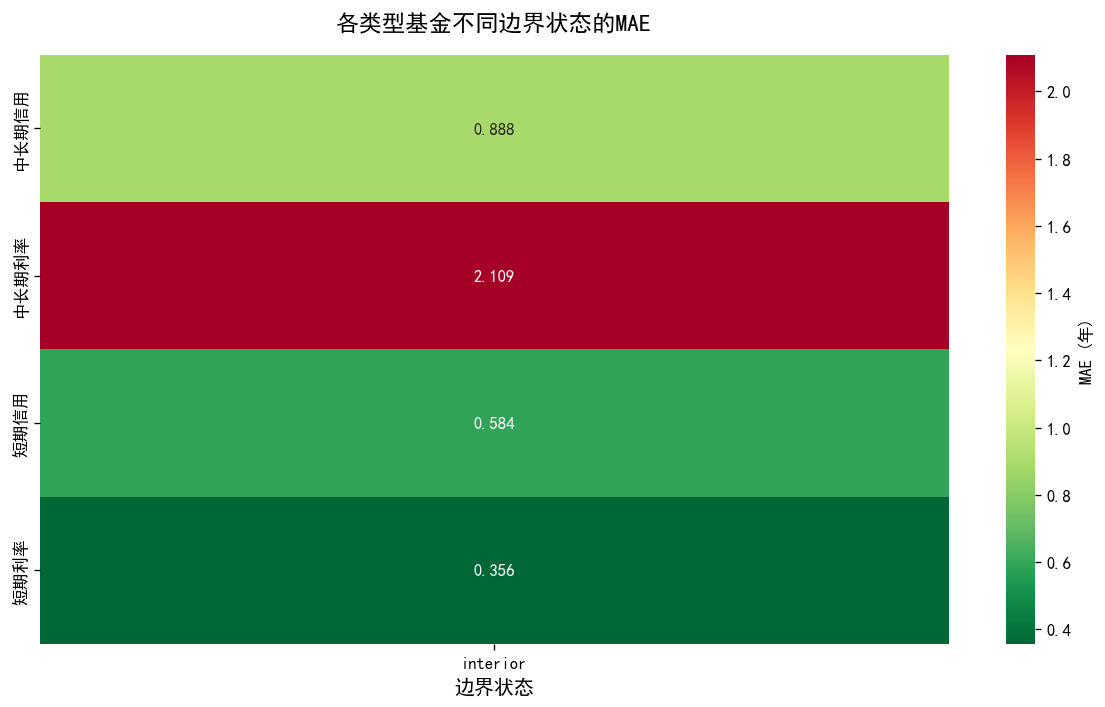

In [59]:
# 图3: 4×3分组MAE热力图
# 创建透视表
pivot_data = detailed_stats.pivot_table(
    index=['fund_type', 'bond_type'],
    columns='boundary_status',
    values='mae'
)

# 只保留存在的列（修正逻辑）
available_cols = [c for c in ['interior', 'upper', 'lower'] if c in pivot_data.columns]
pivot_data = pivot_data[available_cols]

# 创建标签
index_labels = []
for ft, bt in pivot_data.index:
    ft_label = '短期' if ft == 'short' else '中长期'
    bt_label = '信用' if bt == 'credit' else '利率'
    index_labels.append(f'{ft_label}{bt_label}')

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_data.values, annot=True, fmt='.3f', cmap='RdYlGn_r',
           xticklabels=pivot_data.columns, yticklabels=index_labels,
           cbar_kws={'label': 'MAE (年)'}, ax=ax)
ax.set_title('各类型基金不同边界状态的MAE', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('边界状态', fontsize=12)
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('output/边界状态MAE热力图.png', dpi=150, bbox_inches='tight')
plt.show()

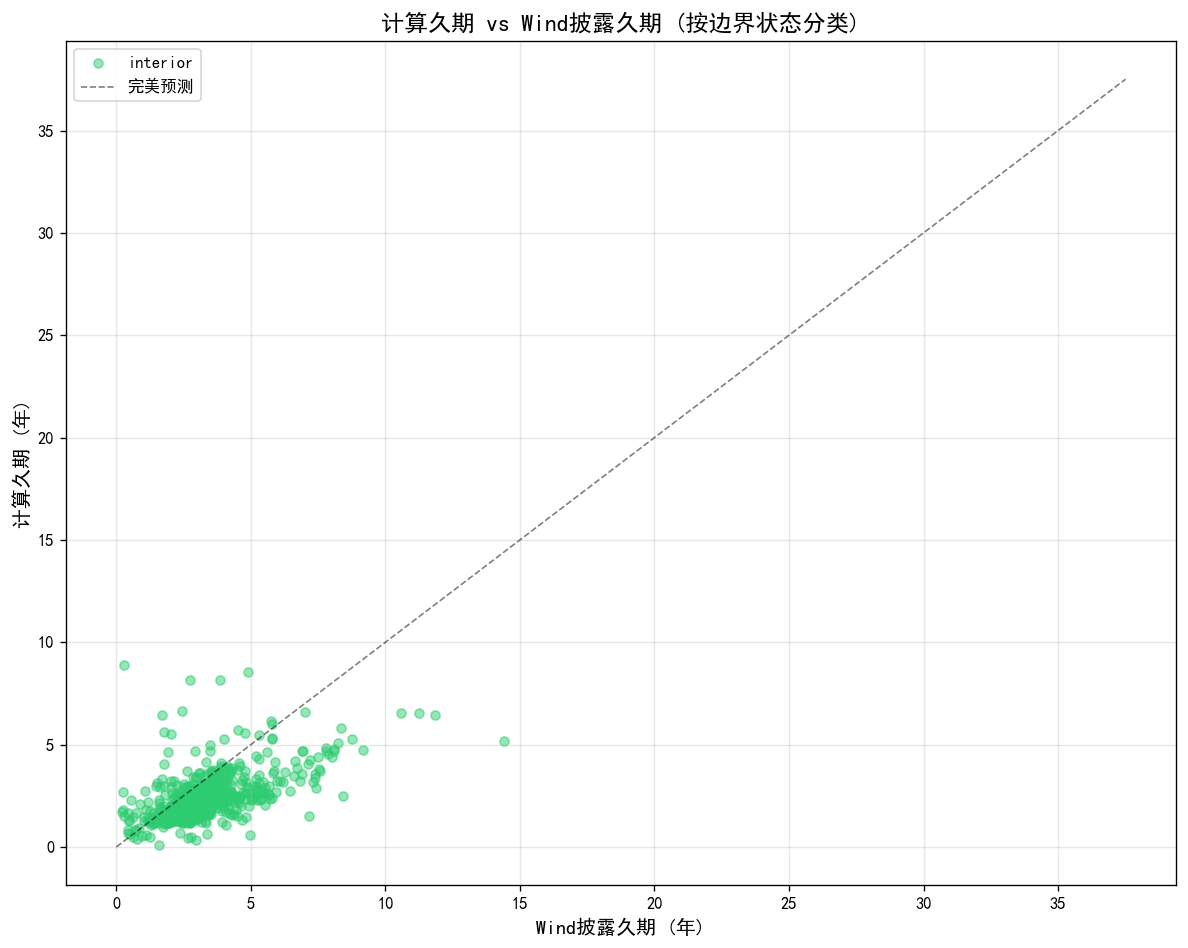

In [60]:
# 图4: 散点图 - 计算久期 vs Wind披露久期
fig, ax = plt.subplots(figsize=(10, 8))

# 定义颜色和标记
color_map = {'interior': '#2ecc71', 'upper': '#e74c3c', 'lower': '#3498db', 'other': '#95a5a6'}
marker_map = {'interior': 'o', 'upper': '^', 'lower': 'v', 'other': 's'}

for status in ['interior', 'upper', 'lower']:
    subset = merged_df[merged_df['boundary_status'] == status]
    if len(subset) > 0:
        ax.scatter(subset['wind_duration'], subset['duration'],  # 修正: calculated_duration -> duration
                  c=color_map.get(status, 'gray'),
                  marker=marker_map.get(status, 'o'),
                  alpha=0.5, s=30, label=status)

# 添加对角线
max_val = max(merged_df['wind_duration'].max(), merged_df['duration'].max())  # 修正
ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1, alpha=0.5, label='完美预测')

ax.set_xlabel('Wind披露久期 (年)', fontsize=12)
ax.set_ylabel('计算久期 (年)', fontsize=12)
ax.set_title('计算久期 vs Wind披露久期 (按边界状态分类)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/计算久期vs披露久期_按边界状态.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 总结与结论

In [61]:
print('\n' + '='*60)
print('总结与结论')
print('='*60)

# 问题1答案
interior_mae = main_groups[main_groups['boundary_status'] == 'interior']['mae'].values
upper_mae = main_groups[main_groups['boundary_status'] == 'upper']['mae'].values
lower_mae = main_groups[main_groups['boundary_status'] == 'lower']['mae'].values

print('\n问题1: 界内解的久期是否比边界解更准确？')
if len(interior_mae) > 0:
    print(f'  界内解MAE: {interior_mae[0]:.3f}年')

if len(upper_mae) > 0 and len(lower_mae) > 0:
    boundary_mae = np.concatenate([upper_mae, lower_mae])
    print(f'  边界解MAE(平均): {boundary_mae.mean():.3f}年')
    if len(interior_mae) > 0:
        print(f'  结论: 界内解{'更准确' if interior_mae[0] < boundary_mae.mean() else '并非更准确'}')
elif len(upper_mae) > 0:
    print(f'  上界解MAE: {upper_mae[0]:.3f}年')
elif len(lower_mae) > 0:
    print(f'  下界解MAE: {lower_mae[0]:.3f}年')
else:
    print('  边界解数据缺失，无法对比')

# 问题2答案
print('\n问题2: 久期偏低和优化到下界是否有因果关系？')
print(f'  下界比例: {lower_count/total_main*100:.1f}%')
print(f'  上界比例: {upper_count/total_main*100:.1f}%')

# 安全地获取各组的平均误差
lower_mean_err = main_groups[main_groups['boundary_status'] == 'lower']['mean_error'].values
upper_mean_err = main_groups[main_groups['boundary_status'] == 'upper']['mean_error'].values

if len(lower_mean_err) > 0:
    print(f'  下界组平均误差: {lower_mean_err[0]:+.3f}年')
if len(upper_mean_err) > 0:
    print(f'  上界组平均误差: {upper_mean_err[0]:+.3f}年')

if len(lower_mean_err) == 0 and len(upper_mean_err) == 0:
    print('  结论: 当前数据中没有边界解(上界/下界)，无法进行因果关系分析。')
    print('        这可能是因为迭代算法的收敛类型识别需要调整，')
    print('        或者需要检查"no_valid_swap"是否应归类为边界解。')
elif lower_count > upper_count:
    lower_mean_err = main_groups[main_groups['boundary_status'] == 'lower']['mean_error'].values[0]
    if lower_mean_err < 0:
        print(f'  结论: 虽然大部分基金优化到下界({lower_count/total_main*100:.0f}%)，')
        print(f'        但下界组平均误差为负({lower_mean_err:.3f})，')
        print(f'        与简单因果假设(应>0)矛盾，说明存在系统性偏差。')
    else:
        print(f'  结论: 下界组平均误差为正，支持因果假设。')
else:
    print(f'  结论: 上界比例更高或无下界数据，简单因果理论预测整体偏低，需进一步分析。')

print('\n' + '='*60)


总结与结论

问题1: 界内解的久期是否比边界解更准确？
  界内解MAE: 1.171年
  边界解数据缺失，无法对比

问题2: 久期偏低和优化到下界是否有因果关系？
  下界比例: 0.0%
  上界比例: 0.0%
  结论: 当前数据中没有边界解(上界/下界)，无法进行因果关系分析。
        这可能是因为迭代算法的收敛类型识别需要调整，
        或者需要检查"no_valid_swap"是否应归类为边界解。



In [62]:
# 导出统计结果
output_file = 'output/边界状态-误差关联统计_20251231.xlsx'
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    boundary_stats.to_excel(writer, sheet_name='按边界状态统计', index=False)
    detailed_stats.to_excel(writer, sheet_name='细分分组统计', index=False)
    
print(f'统计结果已保存到: {output_file}')

统计结果已保存到: output/边界状态-误差关联统计_20251231.xlsx
